<a href="https://colab.research.google.com/github/Mezo-555/AI_Platforms_Assignments/blob/main/Ai_Platforms_Ass4_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN with Pytorch for Fashion MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU and set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device set to: {device}")

PyTorch version: 2.8.0+cu126
Device set to: cuda:0


In [2]:
# Define a pipeline of transformations for the images
transform = transforms.Compose([
    transforms.ToTensor(),         # Convert to Tensor and scale pixels to [0.0, 1.0]
    transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to [-1.0, 1.0]
])

print("Loading Fashion MNIST dataset...")

# Load training and testing datasets, applying the defined transform
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# Define DataLoaders to handle batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Shuffle training data
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Keep test data unshuffled

# Define class names for readability
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Check data shape (get one batch for inspection)
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Batch images shape: {images.shape}") # Expected: (batch_size, 1, 28, 28)
print(f"Batch labels shape: {labels.shape}") # Expected: (batch_size)

Loading Fashion MNIST dataset...
Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])


In [3]:
class FashionCNN(nn.Module):
    # Initializes the network layers
    def __init__(self):
        super(FashionCNN, self).__init__()

        # First Conv/Pool block: Input [1, 28, 28] -> Output [32, 14, 14]
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Second Conv/Pool block: Input [32, 14, 14] -> Output [64, 7, 7]
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully Connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=64*7*7, out_features=128)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=128, out_features=10) # 10 classes output

    # Defines the data flow through the network
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.flatten(x)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate and move the model to the target device
model = FashionCNN().to(device)

print("Building the CNN model...")

Building the CNN model...


In [4]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Setup Loss and Optimizer finished.")

Setup Loss and Optimizer finished.


In [5]:
def evaluate_model(model, data_loader, criterion):
    model.eval() # Set model to evaluation mode
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Disable gradient calculations
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)

            # Get the predicted class index
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item() # Count correct predictions

    avg_loss = test_loss / len(data_loader.dataset) # Calculate average loss
    accuracy = correct / total                       # Calculate accuracy
    return avg_loss, accuracy

In [6]:
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    print("Training the model...")
    # Dictionary to store loss and accuracy history
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (images, labels) in enumerate(train_loader):
            # Move inputs to device
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad() # Clear previous gradients

            # Forward pass, calculate loss
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward() # Backward pass: compute gradients
            optimizer.step() # Update weights

            running_loss += loss.item() * images.size(0)

            # Calculate training accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calculate epoch-level metrics
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train

        # Validation after each epoch
        val_loss, val_acc = evaluate_model(model, test_loader, criterion)

        # Record history
        history['loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(epoch_acc)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    print("Training finished.")
    return history

# Run the training
epochs = 20
history = train_model(model, train_loader, criterion, optimizer, epochs=epochs)

Training the model...
Epoch 1/20 | Loss: 0.5377 | Acc: 0.8074 | Val Loss: 0.3413 | Val Acc: 0.8727
Epoch 2/20 | Loss: 0.3527 | Acc: 0.8751 | Val Loss: 0.2885 | Val Acc: 0.8934
Epoch 3/20 | Loss: 0.3004 | Acc: 0.8912 | Val Loss: 0.2775 | Val Acc: 0.8939
Epoch 4/20 | Loss: 0.2732 | Acc: 0.9019 | Val Loss: 0.2599 | Val Acc: 0.9034
Epoch 5/20 | Loss: 0.2506 | Acc: 0.9094 | Val Loss: 0.2465 | Val Acc: 0.9091
Epoch 6/20 | Loss: 0.2305 | Acc: 0.9156 | Val Loss: 0.2353 | Val Acc: 0.9144
Epoch 7/20 | Loss: 0.2132 | Acc: 0.9202 | Val Loss: 0.2416 | Val Acc: 0.9134
Epoch 8/20 | Loss: 0.1988 | Acc: 0.9259 | Val Loss: 0.2407 | Val Acc: 0.9118
Epoch 9/20 | Loss: 0.1886 | Acc: 0.9290 | Val Loss: 0.2410 | Val Acc: 0.9159
Epoch 10/20 | Loss: 0.1788 | Acc: 0.9336 | Val Loss: 0.2482 | Val Acc: 0.9177
Epoch 11/20 | Loss: 0.1661 | Acc: 0.9374 | Val Loss: 0.2401 | Val Acc: 0.9188
Epoch 12/20 | Loss: 0.1558 | Acc: 0.9408 | Val Loss: 0.2348 | Val Acc: 0.9198
Epoch 13/20 | Loss: 0.1472 | Acc: 0.9434 | Val Loss

In [7]:
# Print a message for context
print("\nEvaluating the model on test data...")

# Call the evaluation function to get final test loss and accuracy
test_loss, test_acc = evaluate_model(model, test_loader, criterion)

# Print the final accuracy
print(f'Test accuracy: {test_acc:.4f}')

# Print the final loss
print(f'Test loss: {test_loss:.4f}')


Evaluating the model on test data...
Test accuracy: 0.9218
Test loss: 0.2920


Plotting training history...


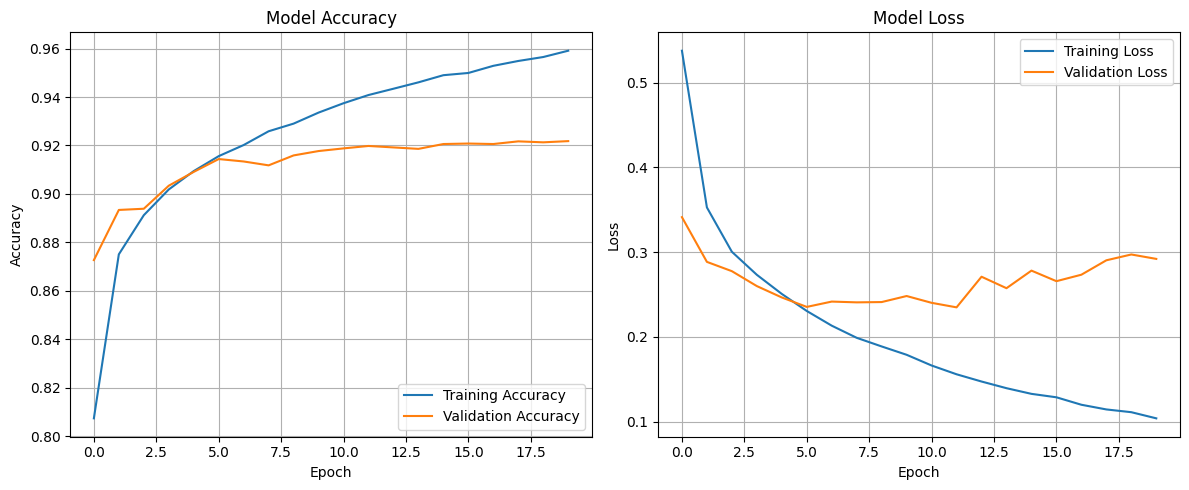

In [8]:
print("Plotting training history...")

# Create a figure for the plots
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Making predictions and visualizing results...


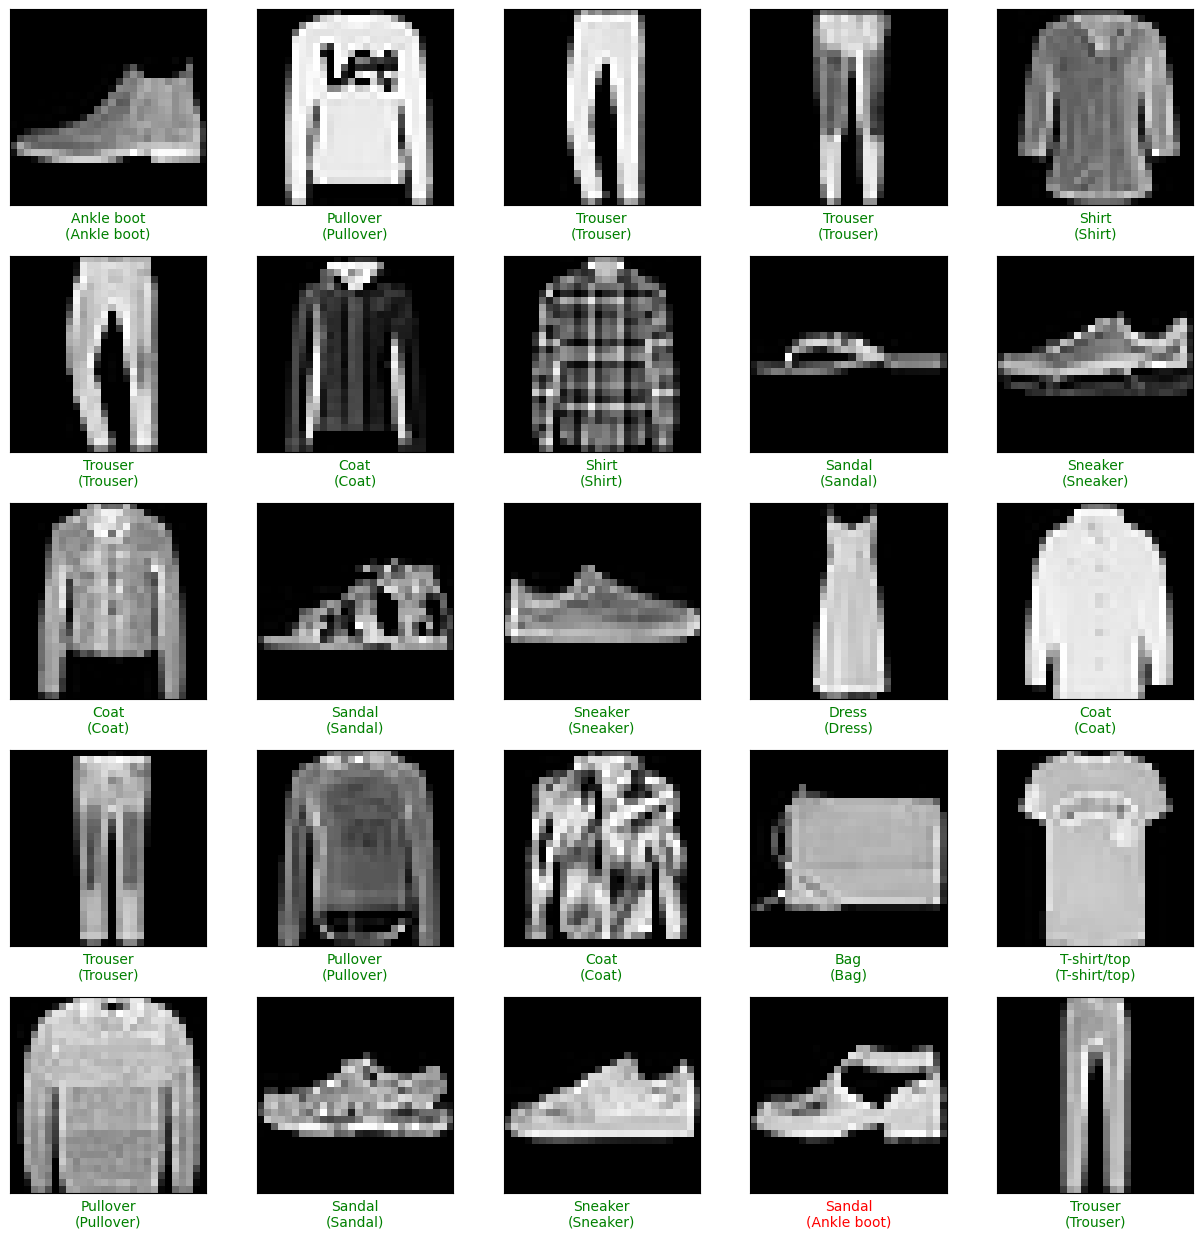

In [9]:
print("Making predictions and visualizing results...")

# Get predictions for the entire test set
model.eval()
all_images = []
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Get the predicted class
        _, predicted = torch.max(outputs.data, 1)

        # Denormalize the images for display (x * 0.5 + 0.5)
        # Note: PyTorch images are [C, H, W]
        images_display = images * 0.5 + 0.5

        all_images.append(images_display.cpu())
        all_labels.append(labels.cpu())
        all_predictions.append(predicted.cpu())

# Concatenate all batches
final_images = torch.cat(all_images)
true_labels = torch.cat(all_labels).numpy()
predicted_labels = torch.cat(all_predictions).numpy()

# Plot a grid of test images, their predicted labels, and true labels
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols

plt.figure(figsize=(num_cols * 2.5, num_rows * 2.5))
for i in range(num_images):
    # Use a 5x5 subplot grid
    plt.subplot(num_rows, num_cols, i + 1)

    # Plot the image (convert from [C, H, W] to [H, W] and numpy)
    plt.imshow(final_images[i].squeeze().numpy(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

    # Get true and predicted labels
    true_label = true_labels[i]
    predicted_label = predicted_labels[i]

    # Set color based on correctness
    color = 'green' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]}\n({class_names[true_label]})", color=color)

plt.tight_layout()
plt.show()

The convolutional neural network (CNN) was successfully trained for 20 epochs to classify clothing items from the Fashion MNIST dataset.

The model's final performance is measured quantitatively by the test accuracy and loss, which are printed to the console after evaluation. This tells us exactly what percentage of unseen images the model classified correctly.

Furthermore, the script generates two key visualizations:


*   Training History Plots: These graphs show how the model's accuracy and loss changed over time during training. By comparing the training lines to the validation lines, you can see how well the model learned and whether it started to overfit (i.e., perform worse on new data than on the data it was trained on).
*   Prediction Visualization: This grid of images provides a qualitative look at the model's performance, showing specific examples of items it identified correctly (in green) and incorrectly (in red). This helps you understand what kind of items the model struggles with.